# 02 Single-market deep dive

Apply the Bayesian-inverse-problem framework to one resolved
Polymarket binary market. We pull the live price-volume history,
align it to the eventual winner so the truth is `Y = 1`, and run the
full diagnostic suite from Section 4 of the paper:

1. **Online posterior trace** `pi_t` overlaid on the market-implied
   probability.
2. **Posterior concentration** by re-evaluating SMC at sub-horizons.
3. **Stability** under Gaussian perturbations of `Delta x` against the
   Theorem 4.4 bound.
4. **Information gain dynamics** `IG(H_t)` plus effective
   informativeness `eta(v_t; theta_hat)`.

In [1]:
from __future__ import annotations
import os, sys
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from pml_market import data, diagnostics, model
from pml_market import (
    InverseProblem, GaussianLatentTypeModel, LatentTypePrior,
    SMCInference, VIInference,
)

# Single inverse problem reused throughout this notebook.
problem = InverseProblem(GaussianLatentTypeModel(), LatentTypePrior())

plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## Pick a market

We auto-discover resolved binary markets from the Gamma API, filter to
those with enough trades and volume, and pick one **uniformly at
random** using `RANDOM_SEED`. Change `RANDOM_SEED` to get a different
draw. Set `OVERRIDE_SLUG` to pin a specific market instead.

In [2]:
OVERRIDE_SLUG: str | None = None  # set to a slug string to pin a specific market
RANDOM_SEED    = 41# change to get a different random draw
BUCKET_MINUTES = 60
MIN_TRADES     = 200
MIN_VOLUME     = 50_000.0
OVERRIDE_SLUG = "fisa-section-702-reauthorized-before-it-expires"
# OVERRIDE_SLUG = "will-trump-endorse-an-israeli-ceasefire-in-lebanon-by-april-30"
# Filter to markets where a specific label won ('Yes', 'No', or None for any).
# y=1 is ALWAYS returned by trajectory_to_arrays (winner-alignment convention).
WINNER_LABEL_FILTER: str | None = None
# Keep only the last LOOKBACK_BUCKETS before resolution (None = full history).
# Useful for long-running markets where early history is noise; the model sees
# only the window ending at resolution.
LOOKBACK_BUCKETS: int | None = None  # e.g. 288 = last 24 h at 5-min buckets
if OVERRIDE_SLUG is not None:
    traj = data.fetch_market_history(OVERRIDE_SLUG, bucket_minutes=BUCKET_MINUTES)
else:
    candidates = data.list_resolved_binary_markets(limit=50, min_volume=MIN_VOLUME)
    print(f'fetched {len(candidates)} resolved binary markets, filtering...')

    valid = []
    for m in candidates:
        try:
            t = data._trajectory_from_market(m, bucket_minutes=BUCKET_MINUTES)
        except Exception:
            continue
        if t['metadata']['trade_count'] < MIN_TRADES:
            continue
        if WINNER_LABEL_FILTER is not None:
            if t['winner_label'].lower() != WINNER_LABEL_FILTER.lower():
                continue
        valid.append(t)

    if not valid:
        raise RuntimeError('no resolved binary with enough trades found '
                           f'(WINNER_LABEL_FILTER={WINNER_LABEL_FILTER!r})')

    rng_pick = np.random.default_rng(RANDOM_SEED)
    pick_idx = int(rng_pick.integers(len(valid)))
    traj = valid[pick_idx]
    print(f'found {len(valid)} valid markets'
          + (f' where winner={WINNER_LABEL_FILTER!r}' if WINNER_LABEL_FILTER else '')
          + f', randomly picked index {pick_idx} (RANDOM_SEED={RANDOM_SEED})')

# Trim to last LOOKBACK_BUCKETS before resolution (full history if None).
full_T = traj['horizon']
if LOOKBACK_BUCKETS is not None:
    traj = data.truncate_trajectory(traj, LOOKBACK_BUCKETS)
    print(f'truncated: full T={full_T} → using last T={traj["horizon"]} buckets '
          f'({traj["horizon"] * BUCKET_MINUTES / 60:.1f} h before resolution)')

SELECTED_SLUG = traj['metadata']['slug']
print(f'\nslug:         {SELECTED_SLUG!r}')
print(f'horizon T:    {traj["horizon"]} buckets  ({traj["horizon"] * BUCKET_MINUTES / 60:.1f} h)')
print(f'winner_label: {traj["winner_label"]!r}  '
      f'(y=1 always — prices flipped to track the winner)')


slug:         'fisa-section-702-reauthorized-before-it-expires'
horizon T:    522 buckets  (522.0 h)
winner_label: 'Yes'  (y=1 always — prices flipped to track the winner)


In [3]:
dx, v, y = data.trajectory_to_arrays(traj)
T = dx.shape[0]

# y is ALWAYS 1 by the winner-alignment convention — trajectory_to_arrays
# flips prices so the winner's probability is tracked regardless of which
# Polymarket label ("Yes"/"No") actually won.  winner_label tells you which.
print(f'Polymarket outcome that won: {traj["winner_label"]!r}')
print(f'winner_index in outcomes list: {traj["winner_index"]}  '
      f'(outcomes = {traj["metadata"]["outcomes"]})')
print(f'y (winner-aligned convention): {y}  ← always 1 by construction')
print()
print(f'T = {T} buckets  ({T * BUCKET_MINUTES / 60:.1f} h)')
print(f'|dx| mean={np.mean(np.abs(dx)):.4f}  0.99-qtile={np.quantile(np.abs(dx), 0.99):.4f}')
print(f'v    mean={v.mean():.2f}  max={v.max():.2f}  zero={( v == 0).mean():.2%}')

Polymarket outcome that won: 'Yes'
winner_index in outcomes list: 0  (outcomes = ['Yes', 'No'])
y (winner-aligned convention): 1  ← always 1 by construction

T = 522 buckets  (522.0 h)
|dx| mean=0.1191  0.99-qtile=1.2021
v    mean=194.93  max=17533.14  zero=64.56%


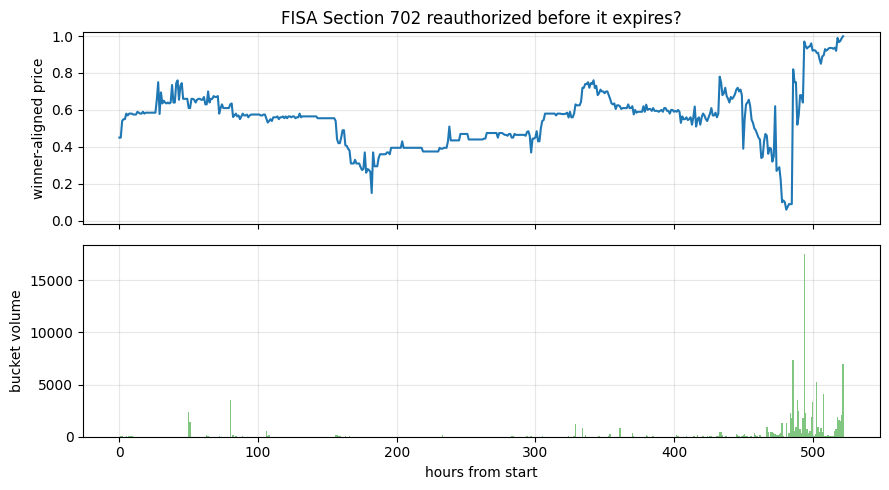

In [4]:
# Plot the raw market history (winner-aligned price + volume)
prices = np.array(traj['prices'])
times = np.array(traj['times']) / 3600.0  # hours since first bucket
times -= times[0]

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(9, 5))
axes[0].plot(times, prices, color='C0')
axes[0].set_ylabel('winner-aligned price')
axes[0].set_ylim(-0.02, 1.02)
axes[0].set_title(f'{traj["metadata"]["question"]}')
axes[1].bar(times[1:], v, width=BUCKET_MINUTES / 60.0, color='C2', alpha=0.6)
axes[1].set_ylabel('bucket volume')
axes[1].set_xlabel('hours from start')
plt.tight_layout()
plt.show()

## (1) Online posterior trace

Run SMC under both outcomes with `record_pi_t=True` so we get
`pi_t = P(Y=1 | H_t)` after every step. Compare to the market-implied
winner-aligned price.

In [5]:
n_particles = 800
smc_engine = SMCInference(n_particles=n_particles, mcmc_steps=4)
smc_res = problem.infer(dx, v, smc_engine, pi0=0.5, seed=0, record_pi_t=True)
print(f'SMC log BF = {smc_res["log_BF"]:+.3f}')
print(f'SMC posterior P(Y=1|H_T) = {smc_res["posterior"]:.4f}  (truth = {y})')

SMC log BF = +27.161
SMC posterior P(Y=1|H_T) = 1.0000  (truth = 1)


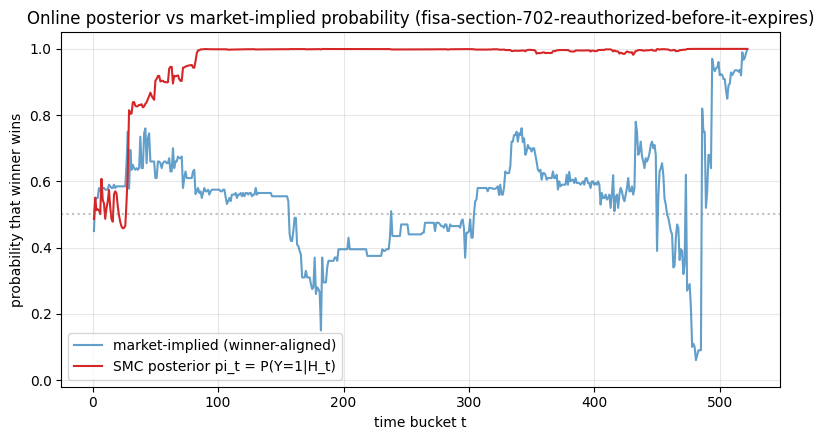

In [6]:
ts = np.arange(1, T + 1)
fig, ax = plt.subplots()
ax.plot(ts, prices[1:], color='C0', alpha=0.7, label='market-implied (winner-aligned)')
ax.plot(ts, smc_res['pi_t'], color='C3', label='SMC posterior pi_t = P(Y=1|H_t)')
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('time bucket t')
ax.set_ylabel('probability that winner wins')
ax.set_title(f'Online posterior vs market-implied probability ({SELECTED_SLUG})')
ax.set_ylim(-0.02, 1.05)
ax.legend(loc='best')
plt.tight_layout()
plt.show()

## (1b) Volume-aware joint model

The default model treats the trade-volume sequence as exogenous: it
conditions on $v_{1:T}$ but never puts probability on it. Following the
factorization

$$p(\Delta x_{1:T}, v_{1:T} \mid Y = y, \theta)
  = p(\Delta x_{1:T} \mid v_{1:T}, Y = y, \theta_{\text{inc}})
  \cdot p(v_{1:T} \mid Y = y, \theta_{\text{vol}}),$$

`VolumeLognormalModel` keeps the original increment factor unchanged and
adds a per-bucket lognormal term
$\log(1 + v_t) \sim \mathcal{N}(\mu_v[Y], \sigma_v[Y]^2)$ as the second
factor. Re-running SMC on the joint likelihood lets the Bayes factor pick
up Y-dependent asymmetries in *trading activity* on top of the
price-direction signal already captured by the standard model.

In [7]:
from pml_market import VolumeLognormalModel, VolumeLognormalPrior

# Same SMC engine, swapped (Model, Prior).
problem_vol = InverseProblem(VolumeLognormalModel(), VolumeLognormalPrior())
smc_vol = SMCInference(n_particles=n_particles, mcmc_steps=4)
smc_res_vol = problem_vol.infer(dx, v, smc_vol, pi0=0.5, seed=0,
                                record_pi_t=True)

print(f'{"":24s}  {"Standard (dx|v,y)":>20s}  {"Volume joint (dx,v|y)":>22s}')
print('-' * 72)
print(f'{"log Bayes factor":24s}  {smc_res["log_BF"]:>+20.3f}  {smc_res_vol["log_BF"]:>+22.3f}')
print(f'{"P(Y=1 | H_T)":24s}  {smc_res["posterior"]:>20.4f}  {smc_res_vol["posterior"]:>22.4f}')
print(f'{"log m_0":24s}  {smc_res["log_m0"]:>20.2f}  {smc_res_vol["log_m0"]:>22.2f}')
print(f'{"log m_1":24s}  {smc_res["log_m1"]:>20.2f}  {smc_res_vol["log_m1"]:>22.2f}')
print(f'\nDelta log BF (volume - standard) = '
      f'{smc_res_vol["log_BF"] - smc_res["log_BF"]:+.3f}  '
      f'(positive => volume term reinforces y=1)')

                             Standard (dx|v,y)   Volume joint (dx,v|y)
------------------------------------------------------------------------
log Bayes factor                       +27.161                -117.494
P(Y=1 | H_T)                            1.0000                  0.0000
log m_0                                 857.69                -1161.76
log m_1                                 884.86                -1279.25

Delta log BF (volume - standard) = -144.655  (positive => volume term reinforces y=1)


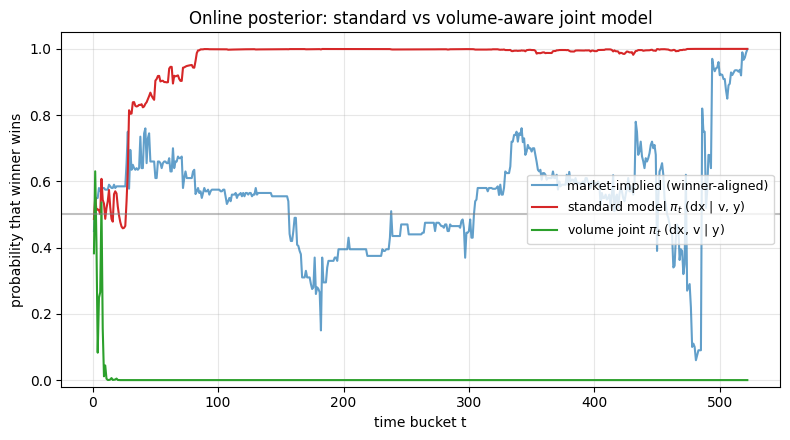

In [8]:
fig, ax = plt.subplots()
ax.plot(ts, prices[1:], color='C0', alpha=0.7,
        label='market-implied (winner-aligned)')
ax.plot(ts, smc_res['pi_t'], color='C3',
        label=r'standard model $\pi_t$ (dx | v, y)')
ax.plot(ts, smc_res_vol['pi_t'], color='C2',
        label=r'volume joint $\pi_t$ (dx, v | y)')
ax.axhline(0.5, color='gray', alpha=0.5)
ax.set_xlabel('time bucket t')
ax.set_ylabel('probability that winner wins')
ax.set_title('Online posterior: standard vs volume-aware joint model')
ax.set_ylim(-0.02, 1.05)
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()

## (1c) Empirical-Bayes asymmetric volume prior

The symmetric `VolumeLognormalPrior` places identical hyperpriors on
the two outcomes,

$$
\mu_v^{(y)} \sim \mathcal N(0,\,10^{2}),
\qquad
\sigma_v^{(y)} \sim \operatorname{HalfNormal}(5),
\qquad y \in \{0, 1\}.
$$

Because the per-bucket factor
$p(v_t \mid Y=y, \theta_{\text{vol}}) =
\operatorname{Lognormal}(v_t;\, \mu_v^{(y)}, (\sigma_v^{(y)})^{2})$
depends on $y$ only through the pair $(\mu_v^{(y)}, \sigma_v^{(y)})$,
and that pair is *exchangeable* under the prior, the prior-predictive
volume marginals are equal:

$$
\int p(v_{1:T} \mid Y=0, \theta)\, \pi(\theta)\, d\theta
\;=\;
\int p(v_{1:T} \mid Y=1, \theta)\, \pi(\theta)\, d\theta .
$$

So the volume factor carries no $Y$-information in expectation, and on a
single market its contribution to $\log m_1 - \log m_0$ is dominated by
Monte-Carlo noise on the difference of two large negative log-marginals.

To make $p(v_{1:T} \mid Y, \theta_{\text{vol}})$ actually informative
about $Y$, we break the prior's $y$-symmetry empirically. Because
volume sequences themselves are invariant to winner-alignment, the
asymmetry has to be tied to the **raw Yes/No label**, not the
winner-aligned $Y=1$ convention used elsewhere in this notebook. We
therefore (i) fit a per-outcome prior on a labeled panel and (ii) run
inference on un-aligned data via `data.trajectory_to_arrays_raw`, which
returns $(\Delta x_{1:T}, v_{1:T}, y_{\text{raw}})$ with
$y_{\text{raw}} = 1 \iff$ the market resolved Yes.

**Fit (method-of-moments).**  Index $y \in \{0=\text{No},\,1=\text{Yes}\}$
and let $\mathcal P_y$ be the markets in the panel that resolved $y$.
For each market $m \in \mathcal P_y$ with volumes $v^{(m)}_{1:T_m}$,
define the per-market log-volume moments

$$
m_m \;=\; \frac{1}{T_m} \sum_{t=1}^{T_m} \log(1 + v^{(m)}_t),
\qquad
s_m \;=\; \sqrt{\tfrac{1}{T_m} \sum_{t=1}^{T_m}
            \bigl(\log(1 + v^{(m)}_t) - m_m\bigr)^{2}} .
$$

Aggregate across markets within each group:

$$
\bar m_y    = \operatorname{mean}_{m \in \mathcal P_y}\, m_m,
\qquad
s_{m,y}     = \operatorname{std}_{m \in \mathcal P_y}\,  m_m,
\qquad
\bar\ell_y  = \operatorname{mean}_{m \in \mathcal P_y}\, \log s_m,
\qquad
s_{\ell,y}  = \operatorname{std}_{m \in \mathcal P_y}\,  \log s_m .
$$

The empirical-Bayes prior `VolumeLognormalEBPrior` then uses

$$
\mu_v^{(y)} \;\sim\; \mathcal N\!\bigl(\bar m_y,\, s_{m,y}^{2}\bigr),
\qquad
\log \sigma_v^{(y)} \;\sim\; \mathcal N\!\bigl(\bar\ell_y,\, s_{\ell,y}^{2}\bigr),
$$

with floors on $s_{m,y}$ and $s_{\ell,y}$ to keep both prior scales
strictly positive on small panels. (Note the parameterization switch
for $\sigma_v$: lognormal instead of HalfNormal, so the prior mode can
be anchored at the empirical scale rather than pinned to $0$.)

In [9]:
from pml_market import VolumeLognormalEBPrior

PANEL_N            = 30
PANEL_BUCKET_MIN   = 5
PANEL_MIN_VOLUME   = 20_000.0
PANEL_MIN_TRADES   = 80
PANEL_CACHE = os.path.join(ROOT, 'cache',
                           f'panel_n{PANEL_N}_b{PANEL_BUCKET_MIN}.json')

panel = data.fetch_resolved_binary_markets(
    n=PANEL_N, bucket_minutes=PANEL_BUCKET_MIN,
    min_volume=PANEL_MIN_VOLUME, min_trades=PANEL_MIN_TRADES,
    cache_path=PANEL_CACHE, verbose=True,
)

# Drop the held-out market from the panel (if present) to avoid leakage.
held_slug = traj['metadata']['slug']
panel_train = [t for t in panel if t['metadata']['slug'] != held_slug]
print(f'panel size: {len(panel)}  (training panel after removing held-out: {len(panel_train)})')

eb_prior, eb_diag = VolumeLognormalEBPrior.from_panel(panel_train)

n_no, n_yes = eb_diag['counts']
print(f'\npanel split: |No|={n_no}  |Yes|={n_yes}  '
      f'(skipped {eb_diag["skipped"]} markets without Yes/No label)')
print(f'\nfitted EB hyperparameters (index 0 = No-resolving, 1 = Yes-resolving):')
print(f'  mu_v_mean       = [{eb_diag["mu_v_mean"][0]:+.3f}, {eb_diag["mu_v_mean"][1]:+.3f}]')
print(f'  mu_v_sd         = [{eb_diag["mu_v_sd"][0]:+.3f}, {eb_diag["mu_v_sd"][1]:+.3f}]')
print(f'  log_sigma_mean  = [{eb_diag["log_sigma_mean"][0]:+.3f}, {eb_diag["log_sigma_mean"][1]:+.3f}]')
print(f'  log_sigma_sd    = [{eb_diag["log_sigma_sd"][0]:+.3f}, {eb_diag["log_sigma_sd"][1]:+.3f}]')
print(f'\n  implied prior mean of sigma_v: '
      f'[{np.exp(eb_diag["log_sigma_mean"][0] + 0.5*eb_diag["log_sigma_sd"][0]**2):.2f}, '
      f'{np.exp(eb_diag["log_sigma_mean"][1] + 0.5*eb_diag["log_sigma_sd"][1]**2):.2f}]')

found 120 candidate resolved markets; pulling histories until we have 30
  [5/30] kept slug='espresso-fdv-above-50m-one-day-after-launch' horizon=1109 trades=252
  [10/30] kept slug='perle-labs-fdv-above-100m-one-day-after-launch' horizon=747 trades=246
  [15/30] kept slug='onefootball-fdv-above-50m-one-day-after-launch-281-682' horizon=3104 trades=828
  [20/30] kept slug='sentio-fdv-above-100m-one-day-after-launch' horizon=13950 trades=663
  [25/30] kept slug='genius-fdv-above-200m-one-day-after-launch' horizon=3755 trades=1109
  [30/30] kept slug='genius-fdv-above-50m-one-day-after-launch' horizon=3679 trades=796
cached 30 trajectories to /Users/natejly/Documents/GitHub/PML-Final/cache/panel_n30_b5.json
panel size: 30  (training panel after removing held-out: 30)

panel split: |No|=12  |Yes|=18  (skipped 0 markets without Yes/No label)

fitted EB hyperparameters (index 0 = No-resolving, 1 = Yes-resolving):
  mu_v_mean       = [+0.741, +0.673]
  mu_v_sd         = [+0.534, +0.519]
  lo

un-aligned trajectory: T=522  y_raw=1  (winner_label='Yes')

(Y=1 here means "Yes resolves"; truth is y_raw=1)

                             standard (dx|v,y)    vol joint, symm prior    vol joint, EB prior
------------------------------------------------------------------------------------------------
log Bayes factor                       +27.161                 -117.494                +29.613
P(Y=Yes | H_T)                          1.0000                   0.0000                 1.0000
log m_0 (Y=No)                          857.69                 -1161.76               -1178.93
log m_1 (Y=Yes)                         884.86                 -1279.25               -1149.31

Delta log BF (vol_sym - standard) = -144.655
Delta log BF (vol_EB  - standard) = +2.452   (asymmetric volume contribution above the increment-only baseline)


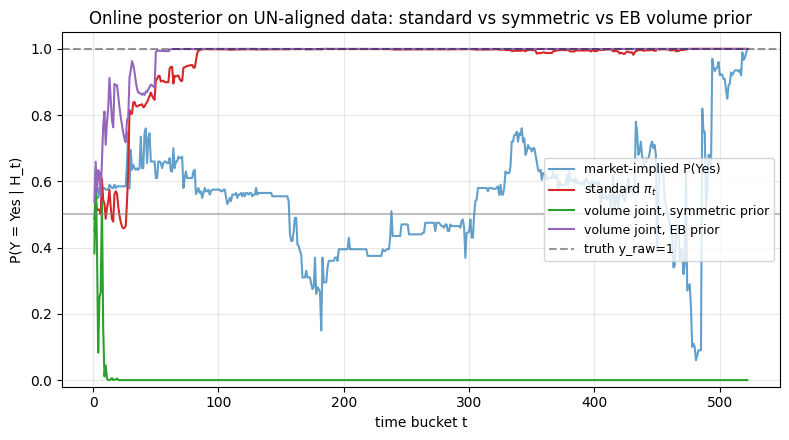

In [10]:
# Run inference on UN-aligned data so the prior's per-Y means line up
# with the model's Y at inference time.  Here Y=1 means "Yes resolves",
# regardless of which side eventually won.
dx_raw, v_raw, y_raw = data.trajectory_to_arrays_raw(traj)
print(f'un-aligned trajectory: T={len(dx_raw)}  y_raw={y_raw}  '
      f'(winner_label={traj["winner_label"]!r})')

# (a) Volume model with the SYMMETRIC prior on un-aligned data.
problem_vol_sym = InverseProblem(VolumeLognormalModel(), VolumeLognormalPrior())
res_vol_sym = problem_vol_sym.infer(dx_raw, v_raw,
                                    SMCInference(n_particles=n_particles, mcmc_steps=4),
                                    pi0=0.5, seed=0, record_pi_t=True)

# (b) Volume model with the EB asymmetric prior on un-aligned data.
problem_vol_eb = InverseProblem(VolumeLognormalModel(), eb_prior)
res_vol_eb = problem_vol_eb.infer(dx_raw, v_raw,
                                  SMCInference(n_particles=n_particles, mcmc_steps=4),
                                  pi0=0.5, seed=0, record_pi_t=True)

# (c) Standard increment-only model on un-aligned data, for reference.
problem_std_raw = InverseProblem(GaussianLatentTypeModel(), LatentTypePrior())
res_std_raw = problem_std_raw.infer(dx_raw, v_raw,
                                    SMCInference(n_particles=n_particles, mcmc_steps=4),
                                    pi0=0.5, seed=0, record_pi_t=True)

print(f'\n(Y=1 here means "Yes resolves"; truth is y_raw={y_raw})\n')
print(f'{"":24s}  {"standard (dx|v,y)":>20s}  '
      f'{"vol joint, symm prior":>23s}  {"vol joint, EB prior":>21s}')
print('-' * 96)
print(f'{"log Bayes factor":24s}  {res_std_raw["log_BF"]:>+20.3f}  '
      f'{res_vol_sym["log_BF"]:>+23.3f}  {res_vol_eb["log_BF"]:>+21.3f}')
print(f'{"P(Y=Yes | H_T)":24s}  {res_std_raw["posterior"]:>20.4f}  '
      f'{res_vol_sym["posterior"]:>23.4f}  {res_vol_eb["posterior"]:>21.4f}')
print(f'{"log m_0 (Y=No)":24s}  {res_std_raw["log_m0"]:>20.2f}  '
      f'{res_vol_sym["log_m0"]:>23.2f}  {res_vol_eb["log_m0"]:>21.2f}')
print(f'{"log m_1 (Y=Yes)":24s}  {res_std_raw["log_m1"]:>20.2f}  '
      f'{res_vol_sym["log_m1"]:>23.2f}  {res_vol_eb["log_m1"]:>21.2f}')

delta_eb = res_vol_eb['log_BF'] - res_std_raw['log_BF']
delta_sym = res_vol_sym['log_BF'] - res_std_raw['log_BF']
print(f'\nDelta log BF (vol_sym - standard) = {delta_sym:+.3f}')
print(f'Delta log BF (vol_EB  - standard) = {delta_eb:+.3f}'
      '   (asymmetric volume contribution above the increment-only baseline)')

# Overlay pi_t for the three models in the un-aligned (Yes-probability) space.
prices_yes = np.asarray(traj['prices'])
if traj['winner_label'] == 'No':
    prices_yes = 1.0 - prices_yes
ts_raw = np.arange(1, len(dx_raw) + 1)
fig, ax = plt.subplots()
ax.plot(ts_raw, prices_yes[1:], color='C0', alpha=0.7,
        label='market-implied P(Yes)')
ax.plot(ts_raw, res_std_raw['pi_t'], color='C3',
        label=r'standard $\pi_t$')
ax.plot(ts_raw, res_vol_sym['pi_t'], color='C2',
        label=r'volume joint, symmetric prior')
ax.plot(ts_raw, res_vol_eb['pi_t'], color='C4',
        label=r'volume joint, EB prior')
ax.axhline(0.5, color='gray', alpha=0.5)
ax.axhline(float(y_raw), color='k', linestyle='--', alpha=0.4,
           label=f'truth y_raw={y_raw}')
ax.set_xlabel('time bucket t')
ax.set_ylabel('P(Y = Yes | H_t)')
ax.set_title('Online posterior on UN-aligned data: standard vs symmetric vs EB volume prior')
ax.set_ylim(-0.02, 1.05)
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()

## (2) Posterior concentration vs sub-horizon

Truncate the history to `T_sub` and re-run SMC for each sub-horizon.
We expect the error `1 - pi_T` to decay roughly exponentially in `T`
once the KL-projection gap is identified (Theorem 4.3).

In [11]:
sub_grid = sorted(set([max(5, T // 10), max(10, T // 5),
                       max(20, T // 3), max(40, T // 2),
                       max(80, T * 3 // 4), T]))
sub_grid = [t for t in sub_grid if t <= T]
errs = []
sub_engine = SMCInference(n_particles=n_particles, mcmc_steps=3)
for Tsub in tqdm(sub_grid, desc='sub-horizons'):
    r = problem.infer(dx[:Tsub], v[:Tsub], sub_engine, pi0=0.5, seed=1)
    errs.append(1.0 - r['posterior'])
    print(f'  T_sub={Tsub:>4d}: posterior={r["posterior"]:.4f}')
errs = np.array(errs)

sub-horizons:   0%|          | 0/6 [00:00<?, ?it/s]

  T_sub=  52: posterior=0.9714
  T_sub= 104: posterior=0.5918
  T_sub= 174: posterior=0.0035
  T_sub= 261: posterior=0.0112
  T_sub= 391: posterior=0.0003
  T_sub= 522: posterior=0.0000


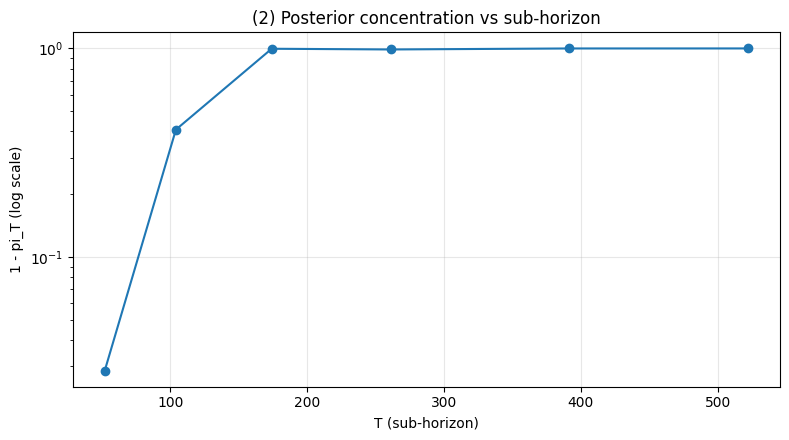

In [12]:
fig, ax = plt.subplots()
ax.plot(sub_grid, np.clip(errs, 1e-6, None), 'o-')
ax.set_yscale('log')
ax.set_xlabel('T (sub-horizon)')
ax.set_ylabel('1 - pi_T (log scale)')
ax.set_title('(2) Posterior concentration vs sub-horizon')
plt.tight_layout()
plt.show()

## (3) Stability to increment perturbations

Add iid Gaussian noise to `Delta x` for several `sigma`, re-run SMC,
and compare `|log BF(h) - log BF(h')|` to the Theorem 4.4 bound with
`Lx = R / sigma_min^2` and `R = 0.99` quantile of `|Delta x|`.

In [14]:
# Use *common random numbers* across base and perturbed: fix the SMC
# seed so that noise from particle randomness cancels and we measure
# only the effect of the perturbation.
sigmas = [0.005, 0.01, 0.02, 0.05, 0.1]
n_trials = 10
# R from full history is fine here: it parameterizes the theoretical bound,
# not the inference itself.
R = float(np.quantile(np.abs(dx), 0.99))
Lx = diagnostics.gaussian_lipschitz_constant(R, sigma_min=0.2)
# Common-random-numbers seed: same SMC randomness for base and perturbed so
# particle noise cancels and we isolate the perturbation effect.
crn_seed = 7777
pert_engine = SMCInference(n_particles=600, mcmc_steps=3)
log_BF_base = problem.infer(dx, v, pert_engine, pi0=0.5, seed=crn_seed)['log_BF']
diffs = []
for s_idx, s in enumerate(sigmas):
    tr = []
    for trial in range(n_trials):
        # Deterministic per-(sigma, trial) seed: perturbations are independent
        # across sigma levels and trials (no shared rng state).
        rng_t = np.random.default_rng(500 + s_idx * 100 + trial)
        dxp = diagnostics.perturb_history(dx, s, rng=rng_t)
        rp = problem.infer(dxp, v, pert_engine, pi0=0.5, seed=crn_seed)
        tr.append(abs(rp['log_BF'] - log_BF_base))
    diffs.append(np.mean(tr))
    print(f'  sigma={s:>5.3f}  mean |delta log BF|={diffs[-1]:.3f}')
diffs = np.array(diffs)
bounds = 2 * Lx * T * np.array(sigmas) * np.sqrt(2 / np.pi)

KeyboardInterrupt: 

In [ ]:
fig, ax = plt.subplots()
ax.plot(sigmas, diffs, 'o-', label="|log BF(h) - log BF(h')|")
ax.plot(sigmas, bounds, '--', label='Theorem 4.4 bound')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('perturbation std sigma')
ax.set_ylabel('|delta log BF|')
ax.set_title('(3) Stability under perturbation')
ax.legend()
plt.tight_layout()
plt.show()

## (4) Information gain and effective informativeness

Plot realized IG(H_t) over time; saturating values indicate the
posterior has concentrated. The effective informativeness `eta(v;theta)`
(Definition 4.3) is computed at the variational-mean theta from VI.

In [ ]:
ig = diagnostics.information_gain_trace(smc_res['pi_t'], pi0=0.5)

# Use VI to get a single theta point estimate (variational mean) for
# eta(v; theta_hat).
vi_engine = VIInference(n_steps=1200, n_samples=8, learning_rate=0.05)
vi_res = problem.infer(dx, v, vi_engine, pi0=0.5, seed=0)
theta_hat = vi_res['vi1']['theta_mean']  # y=1 is correct: prices are winner-aligned
eta = diagnostics.effective_informativeness(v, theta_hat)
print(f'VI log BF = {vi_res["log_BF"]:+.3f}  (SMC: {smc_res["log_BF"]:+.3f})')
print(f'theta_hat omega = {theta_hat["omega"]}')
print(f'theta_hat mu1   = {float(theta_hat["mu1"]):.3f}')
print(f'theta_hat mu3   = {float(theta_hat["mu3"]):.3f}')
print(f'theta_hat tau3  = {float(theta_hat["tau3"]):.3f}')

VI log BF = +0.089  (SMC: +5.791)
theta_hat omega = [0.30121868 0.34249609 0.35628523]
theta_hat mu1   = 0.362
theta_hat mu3   = 0.255
theta_hat tau3  = 3.708


In [ ]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(9, 5))
axes[0].plot(ts, ig, color='C3', label='IG(H_t)')
axes[0].axhline(np.log(2), linestyle='--', color='red', label='log 2 (prior entropy)')
axes[0].set_ylabel('IG (nats)')
axes[0].set_title('(4) Information gain and effective informativeness')
axes[0].legend()

axes[1].plot(ts, eta, color='C2', label='eta(v_t; theta_hat)')
axes[1].axhline(0.0, linestyle=':', color='gray')
axes[1].set_xlabel('time bucket t')
axes[1].set_ylabel('eta')
axes[1].legend()
plt.tight_layout()
plt.show()